In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Input shape:", X.shape)
print("Output shape:", y.shape)
print("Classes:", iris.target_names)

Input shape: (150, 4)
Output shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = tf.cast(X_train, tf.float32)
X_test = tf.cast(X_test, tf.float32)

y_train = tf.cast(y_train, tf.int32)
y_test = tf.cast(y_test, tf.int32)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        16,
        activation='relu',
        input_shape=(4,)
    ),

    tf.keras.layers.Dense(
        8,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        3,
        activation='softmax'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
learning_rate = 0.01

loss_function = tf.keras.losses.SparseCategoricalCrossentropy()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
)

In [ ]:
def forward_propagation(X):
    """
    Performs forward propagation through the neural network.
    """

    output = model(X, training=True)

    return output

In [ ]:
sample_data = X_train[:5]

predictions = forward_propagation(sample_data)

print("Predicted probabilities:")
print(predictions.numpy())

print("\nPredicted classes:")
print(tf.argmax(predictions, axis=1).numpy())

print("\nActual classes:")
print(y_train[:5].numpy())

Predicted probabilities:
[[0.4072796  0.31654143 0.27617896]
 [0.3850419  0.2214395  0.39351857]
 [0.35201007 0.32497233 0.32301757]
 [0.36775246 0.36107185 0.27117565]
 [0.40001827 0.2382986  0.3616831 ]]

Predicted classes:
[0 2 0 0 0]

Actual classes:
[0 2 1 0 1]


In [ ]:
def train_step(X, y):

    #forward propogation
    with tf.GradientTape() as tape:

        # Pass input through the network
        predictions = model(X, training=True)

        # Calculate prediction error
        loss = loss_function(y, predictions)

    #backpropogation
    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    #update weights
    optimizer.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return loss, predictions, gradients

In [ ]:
epochs = 50

loss_history = []
accuracy_history = []

for epoch in range(epochs):

    loss, predictions, gradients = train_step(
        X_train,
        y_train
    )

    predicted_classes = tf.argmax(
        predictions,
        axis=1
    )

    accuracy = tf.reduce_mean(
        tf.cast(
            predicted_classes == tf.cast(y_train, tf.int64),
            tf.float32
        )
    )

    loss_history.append(loss.numpy())
    accuracy_history.append(accuracy.numpy())

    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch {epoch + 1:2d}/{epochs} "
            f"| Loss: {loss.numpy():.4f} "
            f"| Accuracy: {accuracy.numpy():.4f}"
        )

Epoch  5/50 | Loss: 1.0665 | Accuracy: 0.5750
Epoch 10/50 | Loss: 0.9641 | Accuracy: 0.6667
Epoch 15/50 | Loss: 0.8655 | Accuracy: 0.6667
Epoch 20/50 | Loss: 0.7553 | Accuracy: 0.6667
Epoch 25/50 | Loss: 0.6385 | Accuracy: 0.6667
Epoch 30/50 | Loss: 0.5379 | Accuracy: 0.6667
Epoch 35/50 | Loss: 0.4692 | Accuracy: 0.6667
Epoch 40/50 | Loss: 0.4394 | Accuracy: 0.6833
Epoch 45/50 | Loss: 0.4146 | Accuracy: 0.7667
Epoch 50/50 | Loss: 0.3863 | Accuracy: 0.8250


In [ ]:
print("Gradient information:\n")

for i, gradient in enumerate(gradients):

    print(
        f"Layer {i + 1}: "
        f"Gradient shape = {gradient.shape}"
    )

Gradient information:

Layer 1: Gradient shape = (4, 16)
Layer 2: Gradient shape = (16,)
Layer 3: Gradient shape = (16, 8)
Layer 4: Gradient shape = (8,)
Layer 5: Gradient shape = (8, 3)
Layer 6: Gradient shape = (3,)


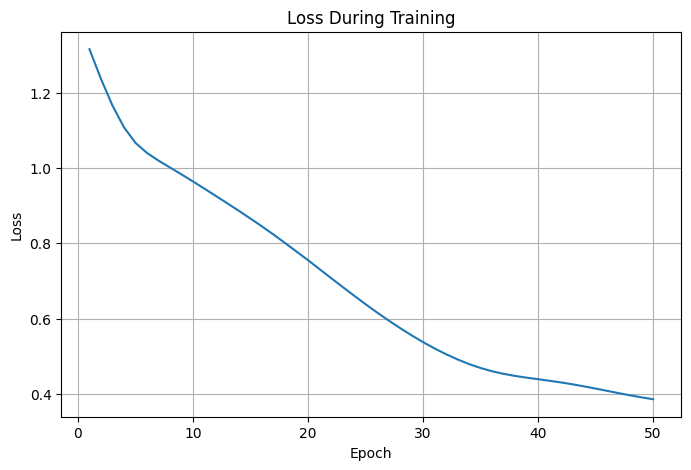

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss During Training")
plt.grid(True)

plt.show()

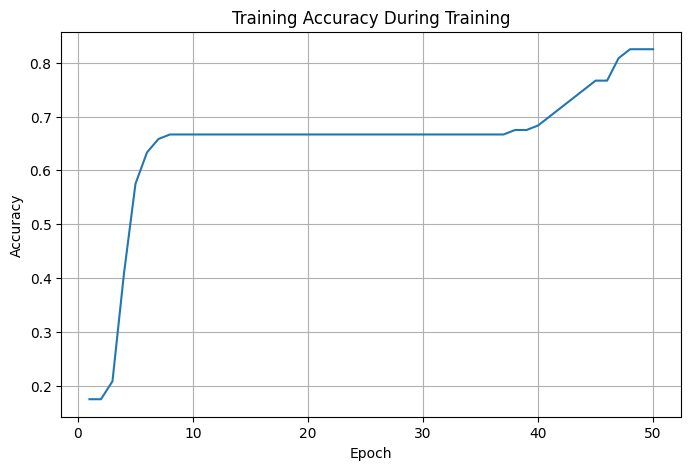

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    accuracy_history
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy During Training")
plt.grid(True)

plt.show()

In [ ]:
test_predictions = model(
    X_test,
    training=False
)

test_classes = tf.argmax(
    test_predictions,
    axis=1
)

test_accuracy = tf.reduce_mean(
    tf.cast(
        test_classes == tf.cast(y_test, tf.int64),
        tf.float32
    )
)

print("Test Accuracy:", test_accuracy.numpy())

Test Accuracy: 0.8


In [ ]:
print("Actual    Predicted")

for actual, predicted in zip(
    y_test.numpy(),
    test_classes.numpy()
):

    print(
        f"{actual:^8} {predicted:^10}"
    )

Actual    Predicted
   0         0     
   2         2     
   1         1     
   1         1     
   0         0     
   1         2     
   0         0     
   0         0     
   2         2     
   1         1     
   2         2     
   2         2     
   2         2     
   1         2     
   0         0     
   0         0     
   0         0     
   1         1     
   1         2     
   2         2     
   0         0     
   2         2     
   1         2     
   2         2     
   2         2     
   1         2     
   1         2     
   0         0     
   2         2     
   0         0     
